# ¿Una gota de sangre que predice si la inmunoterapia funcionará?

**78 pacientes con melanoma.** Antes de empezar el tratamiento: una muestra de sangre, fragmentos de ADN flotando libres (cfDNA) y nueve números calculados desde esa firma. Uno de esos nueve —llamado SE7— predijo quién iba a responder a la inmunoterapia con un AUC de 0.80.

Sin biopsia. Sin tomografía. Solo sangre.

> **Paper:** [Non-invasive profiling of the tumour microenvironment with spatial ecotypes](https://doi.org/10.1038/s41586-026-10452-4)  \
> *Nature, 6 de mayo de 2026 — Newman et al.*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-tme-spatial-ecotypes/notebook.ipynb)

[Pendiente] *video corto del canal en YouTube*

## Qué hicieron exactamente

El equipo integró **más de 10 millones de transcriptomas** —célula a célula y punto a punto— de tumores humanos. Con ese atlas entrenaron un modelo que reconoce nueve patrones recurrentes de organización del microambiente tumoral. Los llamaron **ecosistemas espaciales** (SEs).

Lo importante: esos nueve patrones **se pueden recuperar desde la sangre**. El ADN tumoral que circula libre (cfDNA) conserva la firma de metilación característica de cada ecosistema. Y esa firma, en pacientes con melanoma metastásico, predice quién responde a inmunoterapia.

En este notebook abrimos los Supplementary Materials del paper y verificamos las cifras nosotros mismos:

1. ¿Qué tan buen predictor es SE7 en realidad?
2. ¿Existe SE7 en otros cánceres además de melanoma?
3. ¿Qué tan conservados están los 9 ecosistemas entre 17 tipos de cáncer?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SE_DESTACADO = 'SE7'         # Cambia a 'SE4' para ver el predictor positivo
COHORTE_FOCO = 'All samples'  # 'All samples' | 'Therapy: Anti-PD-1' | 'Subtype: Sun-exposed' ...
AUC_CLINICO = 0.70            # Umbral clínico estándar (AUC > 0.70 = útil)
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_POSITIVO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_NEUTRO = '#7C3AED'
FUENTE_TXT = 'Fuente: Newman et al. (2026), Nature | Tabla S13 y S27 (Supplementary)'

# ── Imports
import os, sys, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ── Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# ── Cargar datos
df_tcga = pd.read_csv('datos/se_abundance_tcga.csv')
df_ici = pd.read_csv('datos/liquid_se_ici_response.csv')

print(f'TCGA: {len(df_tcga):,} muestras × {df_tcga["cancer"].nunique()} tipos de cáncer')
print(f'    Columnas SE: {[c for c in df_tcga.columns if c.startswith("SE")]}')
print(f'ICI: {len(df_ici)} filas (SE × subgrupo) en 78 melanomas pre-tratamiento')
print(f'    Subgrupos: {df_ici["data_group"].nunique()} (incluyendo "All samples")')
print()
print('Conteo de muestras por cáncer (TCGA, top-5):')
print(df_tcga['cancer'].value_counts().head().to_string())

TCGA: 7,076 muestras × 17 tipos de cáncer
    Columnas SE: ['SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7', 'SE8', 'SE9']
ICI: 35 filas (SE × subgrupo) en 78 melanomas pre-tratamiento
    Subgrupos: 10 (incluyendo "All samples")

Conteo de muestras por cáncer (TCGA, top-5):
cancer
BRCA    1104
UCEC     532
HNSC     520
THCA     513
LUAD     508


## El predictor

Aquí está.

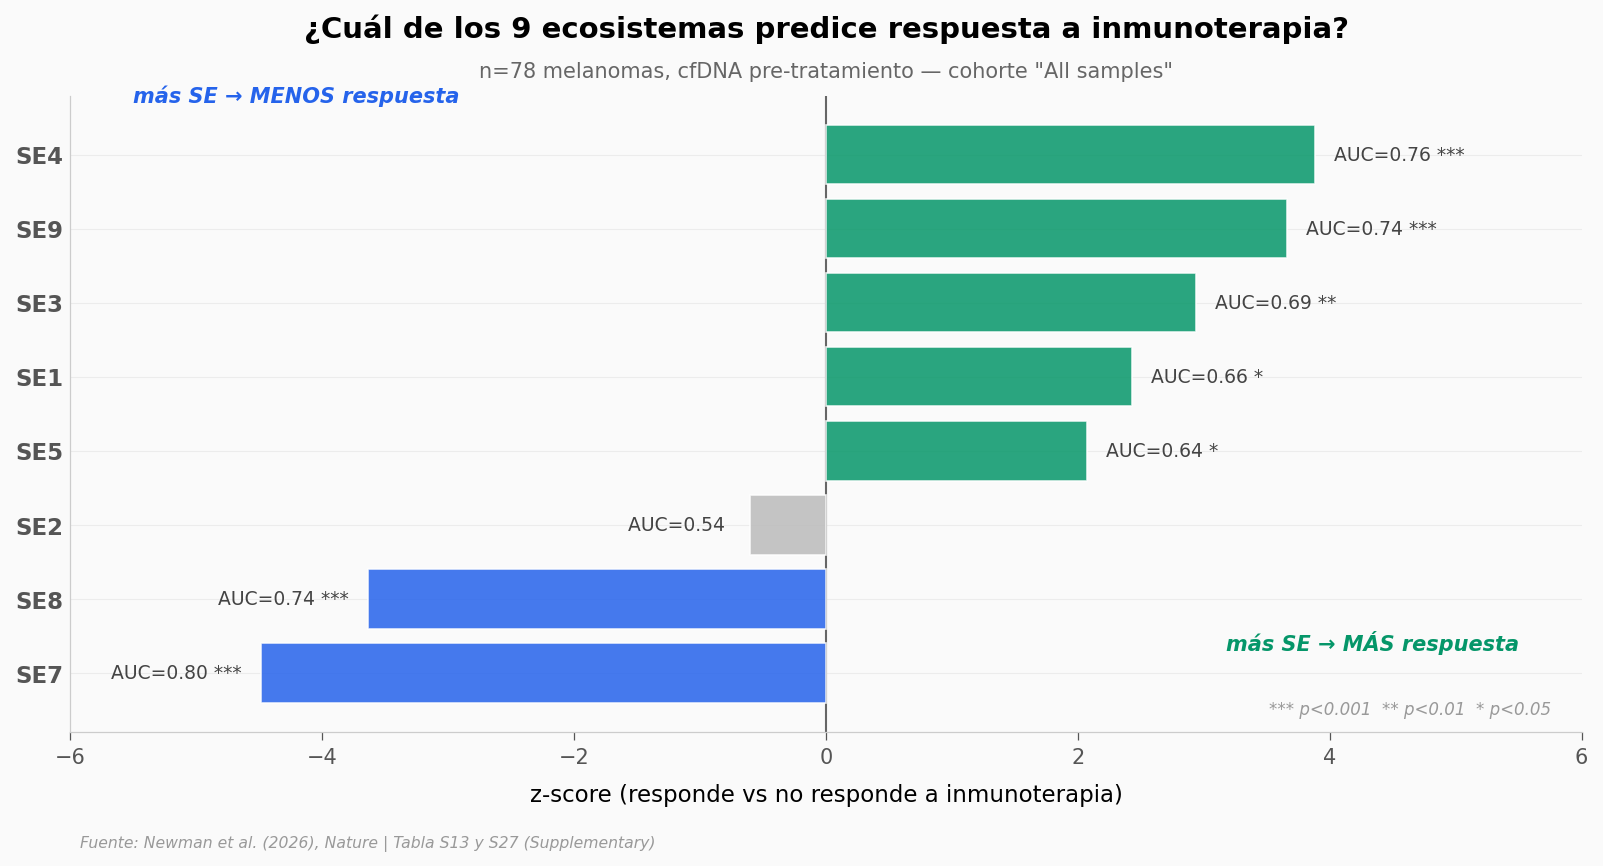

In [2]:
# Gráfica HERO — los 9 ecosistemas como predictores de respuesta a ICI
sub = df_ici[df_ici['data_group'] == COHORTE_FOCO].copy()
sub = sub.sort_values('z_score')

# Asignar color por dirección y significancia (p<0.05)
colores = []
for _, row in sub.iterrows():
    if row['p_value'] >= 0.05:
        colores.append('#BBBBBB')  # no significativo
    elif row['z_score'] < 0:
        colores.append(COLOR_DATOS)  # negativo → menos respuesta
    else:
        colores.append(COLOR_POSITIVO)  # positivo → más respuesta

fig, ax = plt.subplots(figsize=(13, 5.5))
y_pos = np.arange(len(sub))
bars = ax.barh(y_pos, sub['z_score'].values, color=colores, alpha=0.85,
               edgecolor='white', linewidth=0.8, zorder=3)

# Anotar AUC al lado de cada barra
for i, (z, auc, p) in enumerate(zip(sub['z_score'], sub['auc'], sub['p_value'])):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    txt = f'AUC={auc:.2f} {sig}'
    if z > 0:
        ax.text(z + 0.15, i, txt, fontsize=9, va='center', color='#444444')
    else:
        ax.text(z - 0.15, i, txt, fontsize=9, va='center', ha='right', color='#444444')

ax.axvline(x=0, color='#666666', linewidth=1, zorder=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(sub['SE'].values, fontsize=11, fontweight='bold')
ax.set_xlabel('z-score (responde vs no responde a inmunoterapia)', fontsize=11)
ax.set_xlim(-6, 6)
ax.set_title('¿Cuál de los 9 ecosistemas predice respuesta a inmunoterapia?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'n=78 melanomas, cfDNA pre-tratamiento — cohorte "{COHORTE_FOCO}"',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas direccionales
ax.text(-5.5, len(sub) - 0.3, 'más SE → MENOS respuesta',
        fontsize=10, color=COLOR_DATOS, fontweight='bold', style='italic')
ax.text(5.5, 0.3, 'más SE → MÁS respuesta',
        fontsize=10, color=COLOR_POSITIVO, fontweight='bold', ha='right', style='italic')

# Nota de significancia
ax.text(0.98, 0.02, '*** p<0.001  ** p<0.01  * p<0.05',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_TXT, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_ici_z_scores.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

**SE7 y SE4 son señales opuestas.** En la cohorte total de 78 pacientes, **menos SE7 en sangre predice mejor respuesta** a inmunoterapia (AUC=0.80). Y al revés: **más SE4 predice mejor respuesta** (AUC=0.76).

Siete de las ocho SEs analizadas en cfDNA salen significativas (p<0.05). La única que no aporta señal es SE2 (p=0.55, AUC=0.54). Eso indica que el microambiente tumoral, leído desde sangre, **no es ruido** — hay biología consistente que el modelo captura.

Para contexto clínico: un AUC de 0.70 ya se considera **clínicamente útil** en oncología. SE7 está en 0.80. Es comparable a marcadores ya establecidos como PD-L1 — y se mide sin biopsia.

> ⚠️ Esto es **asociacional**, no causal. Los datos muestran que SE7 en cfDNA discrimina responders de no-responders en esta cohorte. No demuestran que reducir SE7 mejore la respuesta.

## ¿Y SE7 existe en otros cánceres?

Si SE7 es solo una rareza del melanoma, este test serviría para muy poca gente. Pero si está presente en todos los tipos de cáncer del atlas TCGA, entonces el modelo capturó algo más fundamental: un patrón universal del microambiente tumoral.

Veamos cuánto SE7 hay en cada tipo de cáncer, usando las 7.076 muestras de TCGA.

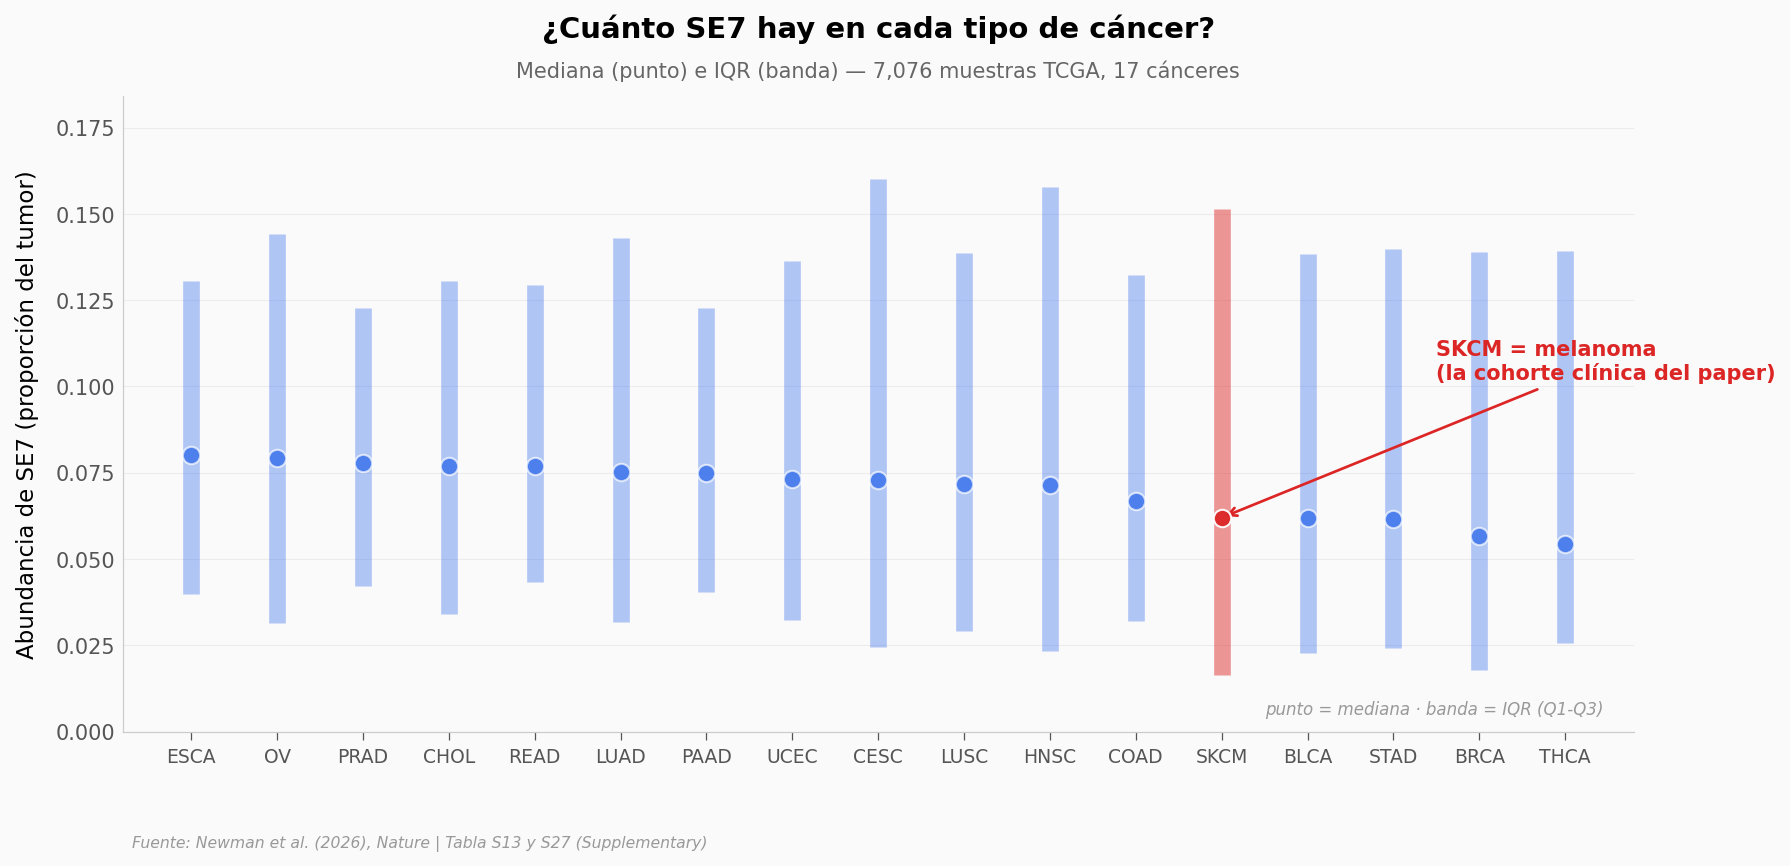


SE7 mediana global: 0.068
SE7 mediana en SKCM (melanoma): 0.062

Top-3 cánceres por mediana de SE7:
        median  count
cancer               
ESCA     0.080    185
OV       0.079    307
PRAD     0.078    498

Bottom-3 cánceres por mediana de SE7:
        median  count
cancer               
STAD     0.062    412
BRCA     0.057   1104
THCA     0.054    513


In [3]:
# Gráfica 2 — SE7 abundance por tipo de cáncer (TCGA)
cancer_order = (df_tcga.groupby('cancer')[SE_DESTACADO]
                       .median()
                       .sort_values(ascending=False)
                       .index.tolist())

# Estadísticas por cáncer
stats_se = (df_tcga.groupby('cancer')[SE_DESTACADO]
                   .agg(['median', 'count',
                         lambda x: x.quantile(0.25),
                         lambda x: x.quantile(0.75)])
                   .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'}))
stats_se = stats_se.loc[cancer_order]

# Resaltar SKCM (melanoma — la cohorte clínica del paper)
colores_cancer = [COLOR_ALERTA if c == 'SKCM' else COLOR_DATOS
                  for c in cancer_order]
alphas = [0.95 if c == 'SKCM' else 0.7 for c in cancer_order]

fig, ax = plt.subplots(figsize=(13, 5.5))
x_pos = np.arange(len(cancer_order))

# IQR como banda + mediana como punto
for i, (c, color, alpha) in enumerate(zip(cancer_order, colores_cancer, alphas)):
    q25 = stats_se.loc[c, 'q25']
    q75 = stats_se.loc[c, 'q75']
    med = stats_se.loc[c, 'median']
    ax.vlines(i, q25, q75, color=color, alpha=alpha*0.5, linewidth=8, zorder=3)
    ax.scatter(i, med, color=color, s=70, alpha=alpha, zorder=5,
               edgecolors='white', linewidths=1.0)

# Anotar SKCM (melanoma)
skcm_idx = cancer_order.index('SKCM')
skcm_med = stats_se.loc['SKCM', 'median']
ax.annotate('SKCM = melanoma\n(la cohorte clínica del paper)',
            xy=(skcm_idx, skcm_med),
            xytext=(skcm_idx + 2.5, skcm_med + 0.04),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

ax.set_xticks(x_pos)
ax.set_xticklabels(cancer_order, fontsize=9, rotation=0)
ax.set_ylabel(f'Abundancia de {SE_DESTACADO} (proporción del tumor)', fontsize=11)
ax.set_title(f'¿Cuánto {SE_DESTACADO} hay en cada tipo de cáncer?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Mediana (punto) e IQR (banda) — {len(df_tcga):,} muestras TCGA, 17 cánceres',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, max(stats_se['q75']) * 1.15)

# Nota
ax.text(0.98, 0.02, 'punto = mediana · banda = IQR (Q1-Q3)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_TXT, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_se7_por_cancer.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n{SE_DESTACADO} mediana global: {df_tcga[SE_DESTACADO].median():.3f}')
print(f'{SE_DESTACADO} mediana en SKCM (melanoma): {skcm_med:.3f}')
print(f'\nTop-3 cánceres por mediana de {SE_DESTACADO}:')
print(stats_se.head(3)[['median', 'count']].round(3).to_string())
print(f'\nBottom-3 cánceres por mediana de {SE_DESTACADO}:')
print(stats_se.tail(3)[['median', 'count']].round(3).to_string())

## Los nueve ecosistemas, lado a lado

SE7 aparece en todos los 17 tipos de cáncer. Su abundancia varía —mayor en cánceres digestivos y reproductivos, menor en tiroides— pero está presente en todos.

¿Y los otros ocho? Si los 9 ecosistemas espaciales son **fundamentales** —como sostiene el paper—, deberíamos ver patrones consistentes entre tipos de cáncer.

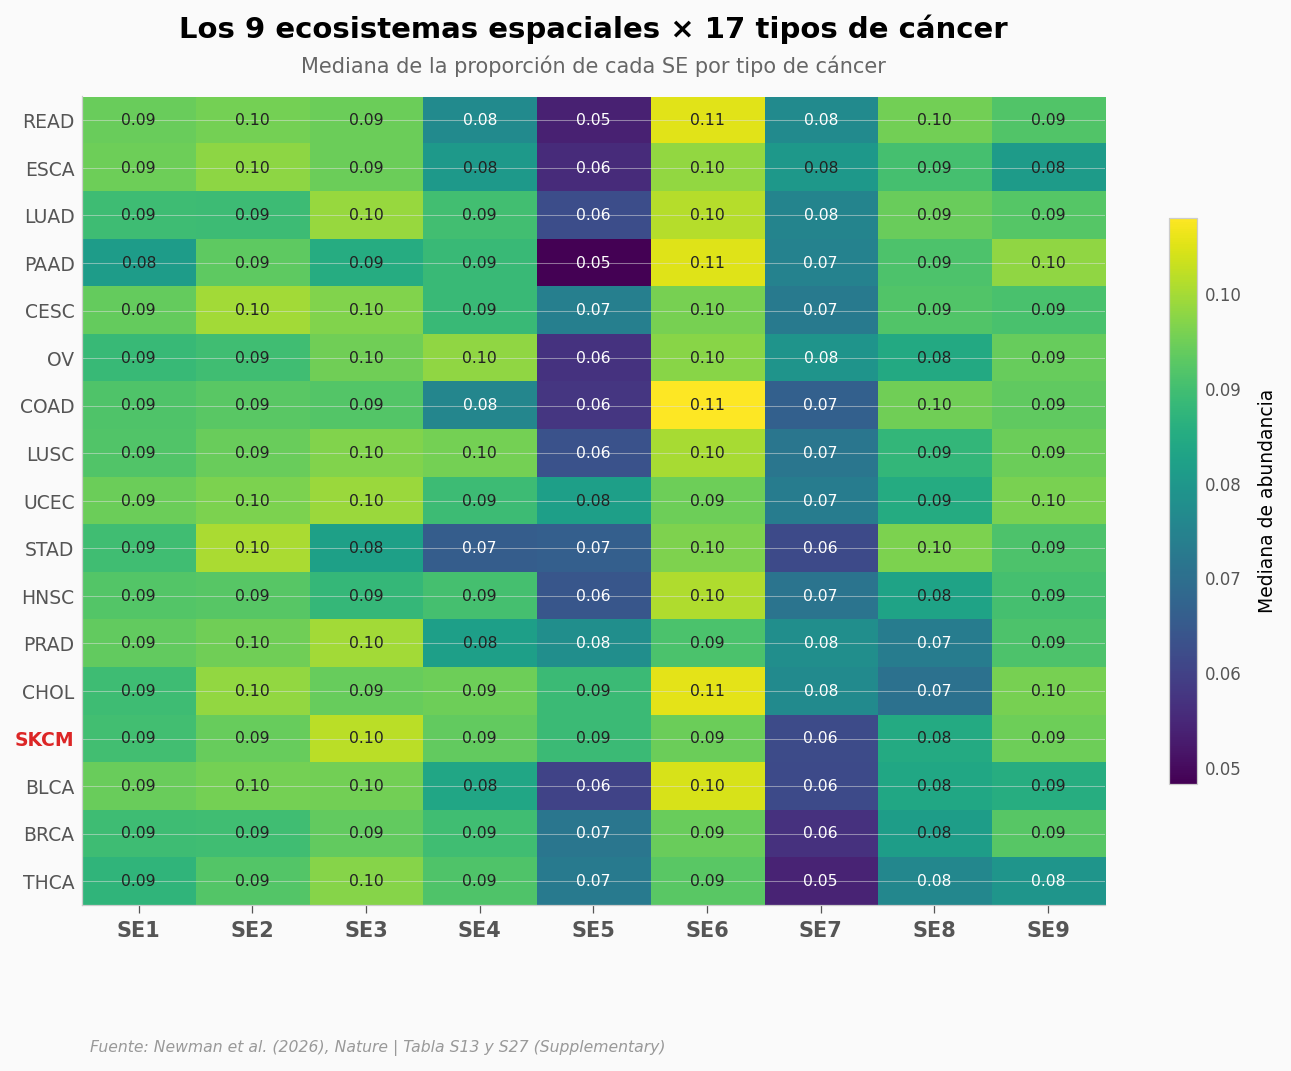

Cánceres con MÁS SE7+SE8 (perfil anti-respuesta):
cancer
READ    0.172
ESCA    0.170
LUAD    0.170

Cánceres con MENOS SE7+SE8:
cancer
BLCA    0.146
BRCA    0.138
THCA    0.130


In [4]:
# Gráfica 3 — Heatmap pan-cancer de las 9 SEs
ses = [f'SE{i}' for i in range(1, 10)]

# Calcular mediana por (cáncer, SE)
heat = df_tcga.groupby('cancer')[ses].median()

# Ordenar cánceres por suma de SE7+SE8 (los anti-respuesta)
heat['_order'] = heat['SE7'] + heat['SE8']
heat = heat.sort_values('_order', ascending=False).drop('_order', axis=1)

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(heat.values, cmap='viridis', aspect='auto')

# Ticks
ax.set_xticks(np.arange(len(ses)))
ax.set_xticklabels(ses, fontsize=10, fontweight='bold')
ax.set_yticks(np.arange(len(heat)))
ax.set_yticklabels(heat.index, fontsize=9)

# Marcar SKCM en el eje Y
for tick in ax.get_yticklabels():
    if tick.get_text() == 'SKCM':
        tick.set_color(COLOR_ALERTA)
        tick.set_fontweight('bold')

# Anotar valores
for i in range(len(heat)):
    for j in range(len(ses)):
        v = heat.values[i, j]
        color = 'white' if v < 0.08 else '#222222'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7.5, color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Mediana de abundancia', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title('Los 9 ecosistemas espaciales × 17 tipos de cáncer',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mediana de la proporción de cada SE por tipo de cáncer',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE_TXT, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_heatmap_9se_x_17cancer.png', dpi=200, bbox_inches='tight')
plt.show()

print('Cánceres con MÁS SE7+SE8 (perfil anti-respuesta):')
top = (df_tcga.groupby('cancer')[['SE7','SE8']].median().sum(axis=1)
       .sort_values(ascending=False).head(3))
print(top.round(3).to_string())
print('\nCánceres con MENOS SE7+SE8:')
bot = (df_tcga.groupby('cancer')[['SE7','SE8']].median().sum(axis=1)
       .sort_values(ascending=False).tail(3))
print(bot.round(3).to_string())

## ¿Qué tan extremo es el melanoma?

El paper midió SE7 en sangre de **78 pacientes con melanoma** y encontró un AUC de 0.80 para predecir respuesta a inmunoterapia. Pero la abundancia de SE7 que estaba midiendo —¿es alta, baja, normal para el universo de 7.076 tumores que tenemos en TCGA?

Vamos a poner al melanoma SKCM en contexto.

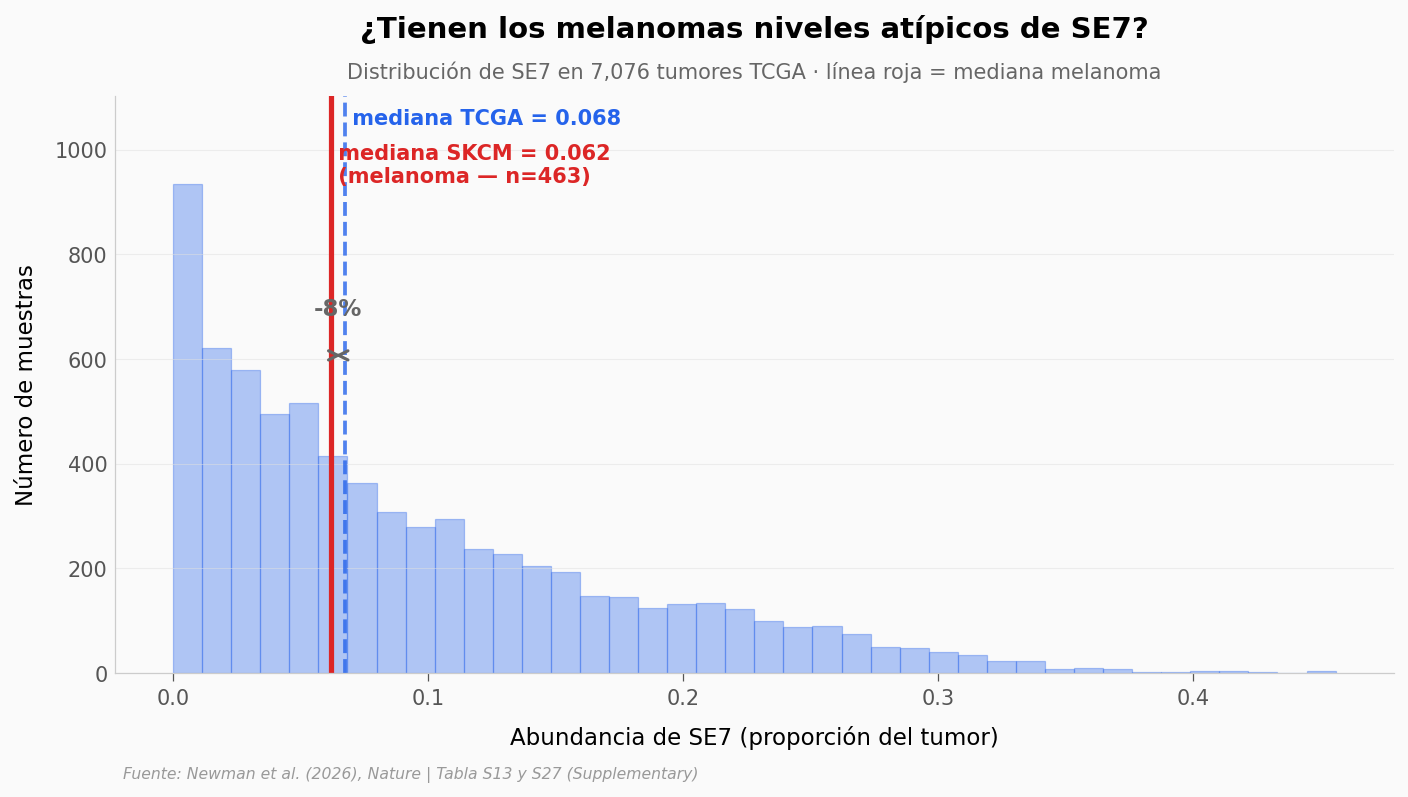

SE7 en TCGA (todos los cánceres):
  mediana = 0.068
  Q1-Q3   = 0.027 - 0.139

SE7 en SKCM (melanoma, n=463):
  mediana = 0.062
  Q1-Q3   = 0.016 - 0.151

Diferencia mediana: -8.3%


In [5]:
# Gráfica 4 — Distribución de SE7 en TCGA, con SKCM marcado
se_vals = df_tcga[SE_DESTACADO].values
skcm_vals = df_tcga[df_tcga['cancer'] == 'SKCM'][SE_DESTACADO].values
mediana_global = np.median(se_vals)
mediana_skcm = np.median(skcm_vals)

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(se_vals, bins=40, color=COLOR_DATOS, alpha=0.35,
                            edgecolor=COLOR_DATOS, linewidth=0.6)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Líneas
ax.axvline(x=mediana_global, color=COLOR_DATOS, linewidth=1.8,
           linestyle='--', alpha=0.8)
ax.axvline(x=mediana_skcm, color=COLOR_ALERTA, linewidth=2.5)

# Etiquetas
ax.text(mediana_global, y_max * 0.95, f' mediana TCGA = {mediana_global:.3f}',
        fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(mediana_skcm, y_max * 0.85, f' mediana SKCM = {mediana_skcm:.3f}\n (melanoma — n={len(skcm_vals)})',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(mediana_skcm, y_max * 0.55),
            xytext=(mediana_global, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_pct = (mediana_skcm - mediana_global) / mediana_global * 100
ax.text((mediana_global + mediana_skcm) / 2, y_max * 0.62,
        f'{diff_pct:+.0f}%', fontsize=11, color='#666666',
        ha='center', fontweight='bold')

ax.set_xlabel(f'Abundancia de {SE_DESTACADO} (proporción del tumor)', fontsize=11)
ax.set_ylabel('Número de muestras', fontsize=11)
ax.set_title(f'¿Tienen los melanomas niveles atípicos de {SE_DESTACADO}?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución de {SE_DESTACADO} en {len(se_vals):,} tumores TCGA · línea roja = mediana melanoma',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE_TXT, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_se7_distribucion_skcm.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{SE_DESTACADO} en TCGA (todos los cánceres):')
print(f'  mediana = {mediana_global:.3f}')
print(f'  Q1-Q3   = {np.percentile(se_vals, 25):.3f} - {np.percentile(se_vals, 75):.3f}')
print(f'\n{SE_DESTACADO} en SKCM (melanoma, n={len(skcm_vals)}):')
print(f'  mediana = {mediana_skcm:.3f}')
print(f'  Q1-Q3   = {np.percentile(skcm_vals, 25):.3f} - {np.percentile(skcm_vals, 75):.3f}')
print(f'\nDiferencia mediana: {diff_pct:+.1f}%')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| SE7 en cfDNA predice no-respuesta a ICI con AUC≈0.80 | ✅ | Table S27, n=78 melanomas, z=-4.49, p=3.1e-6, AUC=0.796 |
| SE4 en cfDNA predice respuesta con AUC≈0.76 | ✅ | Table S27, n=78, z=+3.88, p=7e-5, AUC=0.756 |
| Los 9 SEs son medibles en 17 tipos de cáncer | ✅ | Table S13: 7.076 muestras TCGA cubren los 9 SEs en 17 cánceres |
| Las 9 SEs están "conservadas" entre tipos de cáncer | ⚠️ | Existen en todos, pero la abundancia varía hasta 1.5× entre cánceres (mediana SE7: 0.054 en THCA → 0.080 en ESCA; ver heatmap) — "conservación" aquí es presencia, no nivel uniforme |
| SE7 abre la puerta a personalización de inmunoterapia | ⚠️ | El paper lo enmarca como implicación a futuro; estudio observacional, requiere validación prospectiva |
| Causalidad: modificar SE7 mejoraría respuesta a ICI | ❌ | Solo evidencia asociacional. No se intervino sobre SE7 |

> **Limitaciones del análisis:**
> - Cohorte ICI pequeña (n=78). Subgrupos por sexo bajan a n=25 (mujeres) y n=53 (hombres). El AUC en el subgrupo "Female" llega a 0.90 para SE4 — sospechosamente alto, posible **overfitting** con muestra pequeña.
> - TCGA mezcla estadios, tratamientos previos y origen geográfico. Los rankings de SE entre tipos de cáncer son descriptivos, no causales.
> - Las 9 SEs son una segmentación del paper (estilo NMF). El número exacto depende del método de descomposición — otros equipos podrían encontrar 7 u 11 ecosistemas igual de válidos.
> - SE7+SE8 suman ~20% de cada tumor en promedio, pero su distribución es muy variable (rango intercuartil amplio en la gráfica 2). El paciente promedio no existe.

## Ahora tú

Cambia el valor de `SE_DESTACADO` en la celda de configuración y vuelve a correr el notebook. Algunas preguntas para guiarte:

**1. ¿Cómo se comporta SE4 (el predictor positivo opuesto)?**
- Cambia `SE_DESTACADO = 'SE4'` y mira si su distribución en SKCM es más alta o más baja que en otros cánceres.
- Pista: SE4 es el segundo más fuerte (AUC=0.76 positivo). ¿Está más concentrado en algún cáncer?

**2. ¿El AUC alto del subgrupo "Female" es real o ruido?**
- En la celda siguiente, cambia `COHORTE_FOCO` a `'Female'` y vuelve a correr la celda 4. ¿Cuántos pacientes son? ¿Confías en ese AUC?
- Pista clínica: AUC>0.90 con n<30 casi siempre es overfitting.

**3. ¿Qué cánceres tienen el perfil "anti-respuesta" más fuerte?**
- Suma `SE7 + SE8` por cáncer en TCGA. ¿Coinciden con los cánceres donde la inmunoterapia funciona peor en la práctica clínica?
- Pista: pancreático (PAAD) suele ser refractario a ICI. ¿Sale alto en SE7+SE8?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Explora los AUC en TODOS los subgrupos del archivo ICI

print('Predictores significativos (p<0.05) por subgrupo:\n')
sig = df_ici[df_ici['p_value'] < 0.05].sort_values(['data_group', 'auc'], ascending=[True, False])
for grupo, g in sig.groupby('data_group'):
    n = g['n_samples'].iloc[0]
    print(f'  {grupo} (n={n})')
    for _, row in g.iterrows():
        flag = ' ⚠️ sospechoso (n pequeña + AUC alto)' if (n < 30 and row['auc'] > 0.85) else ''
        print(f'    {row["SE"]}: z={row["z_score"]:+.2f}  AUC={row["auc"]:.2f}  p={row["p_value"]:.4f}{flag}')
    print()

Predictores significativos (p<0.05) por subgrupo:

  Age <65 (n=36)
    SE7: z=-2.62  AUC=0.76  p=0.0081
    SE4: z=+2.42  AUC=0.74  p=0.0147
    SE8: z=-2.07  AUC=0.70  p=0.0389

  Age >=65 (n=42)
    SE7: z=-3.35  AUC=0.81  p=0.0005
    SE8: z=-3.27  AUC=0.81  p=0.0007
    SE4: z=+3.08  AUC=0.79  p=0.0016

  All samples (n=78)
    SE7: z=-4.49  AUC=0.80  p=0.0000
    SE4: z=+3.88  AUC=0.76  p=0.0001
    SE9: z=+3.66  AUC=0.74  p=0.0002
    SE8: z=-3.64  AUC=0.74  p=0.0002
    SE3: z=+2.94  AUC=0.69  p=0.0030
    SE1: z=+2.43  AUC=0.66  p=0.0149
    SE5: z=+2.07  AUC=0.64  p=0.0380

  BRAF: mutant (n=27)
    SE7: z=-2.47  AUC=0.78  p=0.0125
    SE4: z=+2.28  AUC=0.76  p=0.0222
    SE8: z=-2.04  AUC=0.73  p=0.0427

  BRAF: wild type (n=38)
    SE4: z=+3.30  AUC=0.82  p=0.0006
    SE7: z=-2.87  AUC=0.78  p=0.0033
    SE8: z=-2.15  AUC=0.71  p=0.0316

  Female (n=25)
    SE4: z=+3.43  AUC=0.90  p=0.0003 ⚠️ sospechoso (n pequeña + AUC alto)
    SE8: z=-3.37  AUC=0.90  p=0.0003 ⚠️ sospecho

## Créditos y datos

- **Paper:** Newman et al. "Non-invasive profiling of the tumour microenvironment with spatial ecotypes". *Nature* (6 mayo 2026). DOI: [10.1038/s41586-026-10452-4](https://doi.org/10.1038/s41586-026-10452-4)
- **Datos:** Supplementary Materials del paper (Tables S13 y S27 del archivo MOESM3). De libre acceso bajo el modelo de Nature.
- **Repositorios públicos del paper:** GEO accession [GSE320042](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE320042) (datos crudos) y [Stanford / Redivis](https://doi.org/10.25936/pm3t-cn37) (datos preprocesados). Código en [github.com/digitalcytometry/spatialecotyper](https://github.com/digitalcytometry/spatialecotyper).
- **Repo de este notebook:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia CC BY 4.0

## Fuentes

**Paper**: [Non-invasive profiling of the tumour microenvironment with spatial ecotypes](https://doi.org/10.1038/s41586-026-10452-4)  
*Nature, 2026-05-06*

**Supplementary Material**: [Supplementary Table 13: SE abundances in melanoma and 16 types of carcinoma from TCGA](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10452-4/MediaObjects/41586_2026_10452_MOESM3_ESM.xlsx)

**Supplementary Material**: [Supplementary Table 27: Associations between liquid SEs and ICI response in 78 melanoma patients](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10452-4/MediaObjects/41586_2026_10452_MOESM3_ESM.xlsx)

**Dataset canónico**: [Gene Expression Omnibus accession GSE320042 — de-identified genomic data](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE320042)

**Dataset canónico**: [Spatial EcoTyper preprocessed and normalized data](https://doi.org/10.25936/pm3t-cn37)

**Código**: [digitalcytometry/spatialecotyper](https://github.com/digitalcytometry/spatialecotyper)

*15 afirmaciones del notebook verificadas contra estas fuentes*